# 05 — SLA Risk Prediction
Predict SLA **breach probability** from intake-known features. EDA → leakage-safe frame → temporal backtest → bake-off (grain A per-metric vs B single+feature; LogReg vs HistGBM ± calibration) → decision.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import nbutils
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

df = nbutils.build_sla_frame()
print(f'{len(df):,} SLA metric instances | breach rate {df.label.mean():.3f}')
print('by metric:', df.groupby('metric').label.mean().round(3).to_dict())
df.head(3)

13,324 SLA metric instances | breach rate 0.266
by metric: {'reply_time': 0.283, 'resolution_time': 0.243}


,ticket_id,metric,instance_id,label,id,priority,ticket_type,group_id,organization_id,created_at,...,tags,via,hour,weekday,month,is_weekend,channel,n_tags,sla_target_min,queue
0,1001,reply_time,0,1,1001,high,incident,907,800011,2025-11-21 06:16:57+00:00,...,"[incident_report, lang_es, service_disruption,...","{'channel': 'email', 'source': {'from': {'addr...",6,4,11,0,email,6,30,Tier 1 - Technical Support
1,1001,resolution_time,0,1,1001,high,incident,907,800011,2025-11-21 06:16:57+00:00,...,"[incident_report, lang_es, service_disruption,...","{'channel': 'email', 'source': {'from': {'addr...",6,4,11,0,email,6,480,Tier 1 - Technical Support
2,1002,reply_time,0,0,1002,low,question,901,800031,2025-07-30 13:55:26+00:00,...,"[customer_service, lang_de, order_issue, produ...","{'channel': 'email', 'source': {'from': {'addr...",13,2,7,0,email,6,240,Customer Service


## EDA — where do breaches concentrate?

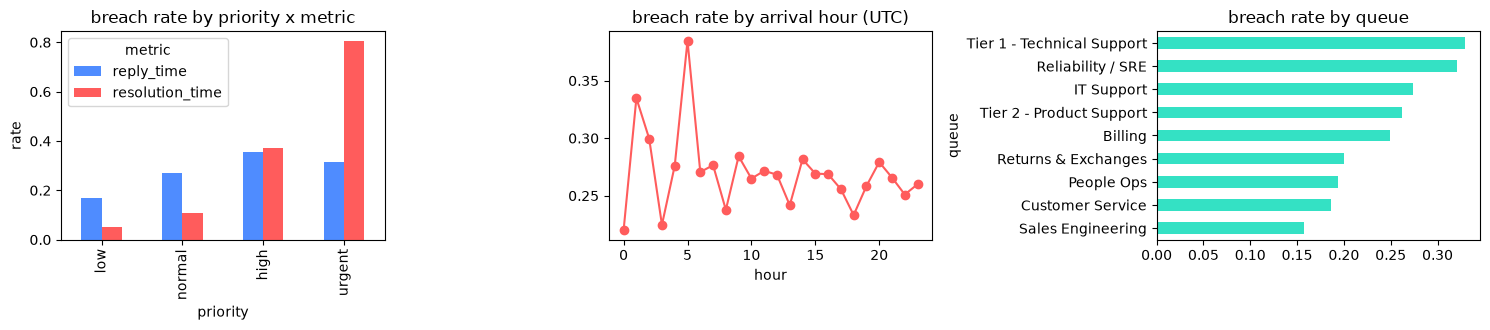

class balance: {0: 9777, 1: 3547}


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
piv = df.pivot_table('label', 'priority', 'metric', 'mean').reindex(['low','normal','high','urgent'])
piv.plot(kind='bar', ax=ax[0], color=['#4f8cff','#ff5c5c']); ax[0].set_title('breach rate by priority x metric'); ax[0].set_ylabel('rate')
df.groupby('hour').label.mean().plot(ax=ax[1], marker='o', color='#ff5c5c'); ax[1].set_title('breach rate by arrival hour (UTC)'); ax[1].set_xlabel('hour')
df.groupby('queue').label.mean().sort_values().plot(kind='barh', ax=ax[2], color='#34e1c4'); ax[2].set_title('breach rate by queue')
plt.tight_layout(); plt.show()
print('class balance:', df.label.value_counts().to_dict())

## Leakage-safe features + temporal split (train H1 / test H2)

In [3]:
CAT = ['priority','ticket_type','queue','metric','channel','locale']
NUM = ['sla_target_min','hour','weekday','month','is_weekend','n_tags']
EXCLUDED = ['reply_time_in_minutes','first_resolution_time_in_minutes','full_resolution_time_in_minutes',
            'replies','reopens','agent_wait_time_in_minutes','requester_wait_time_in_minutes','on_hold_time_in_minutes','solved_at']
assert not (set(EXCLUDED) & set(CAT+NUM)), 'leakage: an outcome column is in the feature set'
assert not (set(EXCLUDED) & set(df.columns)), 'leakage: an outcome column is in the frame'
print('no-leakage check passed')

df_s = df.sort_values('created_at')
split = df_s['created_at'].median()
train = df_s[df_s['created_at'] < split]; test = df_s[df_s['created_at'] >= split]
print(f'train {len(train):,} (breach {train.label.mean():.3f}) | test {len(test):,} (breach {test.label.mean():.3f}) | split {split.date()}')

# consistent categorical encoding across train/test
def cat_frame(part):
    X = part[CAT+NUM].copy()
    for c in CAT:
        cats = df[c].fillna('NA').astype(str).unique()
        X[c] = pd.Categorical(part[c].fillna('NA').astype(str), categories=cats)
    return X
def str_frame(part):
    X = part[CAT+NUM].copy()
    for c in CAT: X[c] = part[c].fillna('NA').astype(str)
    return X
ytr, yte = train.label.values, test.label.values

no-leakage check passed
train 6,661 (breach 0.266) | test 6,663 (breach 0.266) | split 2026-01-23


## Bake-off — prior baseline · LogReg · HistGBM · calibrated · per-metric (grain A)

In [4]:
def ev(name, y, p): return {'model':name,'roc_auc':round(roc_auc_score(y,p),3),'pr_auc':round(average_precision_score(y,p),3),'brier':round(brier_score_loss(y,p),4)}
rows = []

# prior: train breach rate by (priority, metric)
rate = train.groupby(['priority','metric']).label.mean()
p_prior = np.array([rate.get((r.priority, r.metric), ytr.mean()) for r in test.itertuples()])
rows.append(ev('prior (priority x metric rate)', yte, p_prior))

# grain B — LogReg
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), CAT)], remainder='passthrough')
lr = Pipeline([('pre',pre),('clf',LogisticRegression(max_iter=1000))]).fit(str_frame(train), ytr)
rows.append(ev('LogReg (B)', yte, lr.predict_proba(str_frame(test))[:,1]))

# grain B — HistGBM (raw + isotonic-calibrated)
def hgb(): return HistGradientBoostingClassifier(categorical_features='from_dtype', random_state=0, max_iter=300, learning_rate=0.05)
Xtr_c, Xte_c = cat_frame(train), cat_frame(test)
m_hgb = hgb().fit(Xtr_c, ytr); p_hgb = m_hgb.predict_proba(Xte_c)[:,1]
rows.append(ev('HistGBM (B)', yte, p_hgb))
m_cal = CalibratedClassifierCV(hgb(), method='isotonic', cv=3).fit(Xtr_c, ytr); p_cal = m_cal.predict_proba(Xte_c)[:,1]
rows.append(ev('HistGBM+isotonic (B)', yte, p_cal))

# grain A — one HistGBM per metric
CAT_A = [c for c in CAT if c != 'metric']
p_a = np.zeros(len(test))
for mt in ['reply_time','resolution_time']:
    trm, tem = train[train.metric==mt], test[test.metric==mt]
    def cf(part):
        X = part[CAT_A+NUM].copy()
        for c in CAT_A:
            cats = df[c].fillna('NA').astype(str).unique(); X[c]=pd.Categorical(part[c].fillna('NA').astype(str),categories=cats)
        return X
    mm = hgb().fit(cf(trm), trm.label.values)
    p_a[(test.metric==mt).values] = mm.predict_proba(cf(tem))[:,1]
rows.append(ev('HistGBM per-metric (A)', yte, p_a))

results = pd.DataFrame(rows).set_index('model')
print(results.to_string())
results

                                roc_auc  pr_auc   brier
model                                                  
prior (priority x metric rate)    0.699   0.433  0.1723
LogReg (B)                        0.720   0.525  0.1687
HistGBM (B)                       0.753   0.571  0.1593
HistGBM+isotonic (B)              0.750   0.561  0.1566
HistGBM per-metric (A)            0.746   0.561  0.1687


,roc_auc,pr_auc,brier
model,,,
prior (priority x metric rate),0.699,0.433,0.1723
LogReg (B),0.720,0.525,0.1687
HistGBM (B),0.753,0.571,0.1593
HistGBM+isotonic (B),0.750,0.561,0.1566
HistGBM per-metric (A),0.746,0.561,0.1687


## Calibration + drivers for the leading model

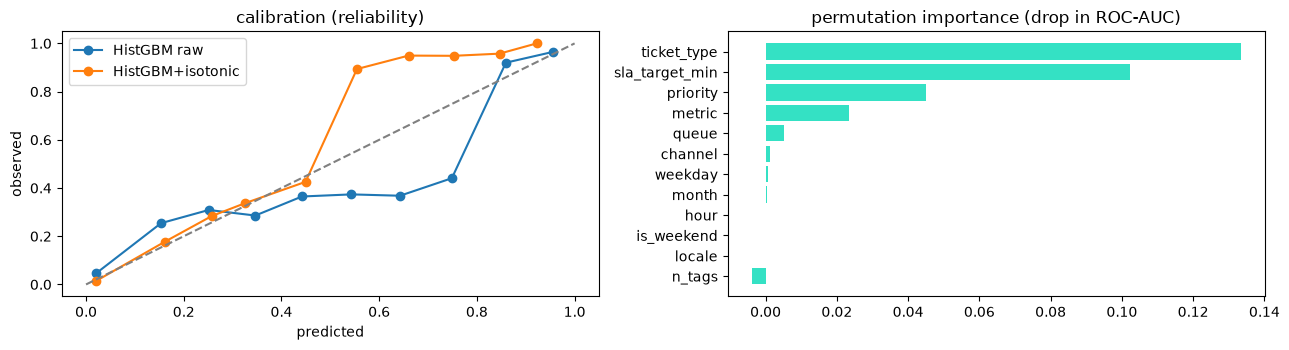

top drivers: [('ticket_type', np.float64(0.133)), ('sla_target_min', np.float64(0.102)), ('priority', np.float64(0.045)), ('metric', np.float64(0.024)), ('queue', np.float64(0.005))]


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for name, p in [('HistGBM raw', p_hgb), ('HistGBM+isotonic', p_cal)]:
    frac, mean = calibration_curve(yte, p, n_bins=10)
    ax[0].plot(mean, frac, marker='o', label=name)
ax[0].plot([0,1],[0,1],'--',color='gray'); ax[0].set_title('calibration (reliability)'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('observed'); ax[0].legend()

imp = permutation_importance(m_hgb, Xte_c, yte, n_repeats=5, random_state=0, scoring='roc_auc')
order = np.argsort(imp.importances_mean)
ax[1].barh(np.array(CAT+NUM)[order], imp.importances_mean[order], color='#34e1c4')
ax[1].set_title('permutation importance (drop in ROC-AUC)')
plt.tight_layout(); plt.show()
drivers = sorted(zip(CAT+NUM, imp.importances_mean), key=lambda x:-x[1])[:5]
print('top drivers:', [(f, round(v,3)) for f,v in drivers])

## Staffing overlay shape (deterministic lever)
Baseline risk `p0` from the model is scaled by how stressed the queue×hour is: `p = clip(p0 * m(u), 0, 1)` where `u = required/available`. Illustrating `m(u)`.

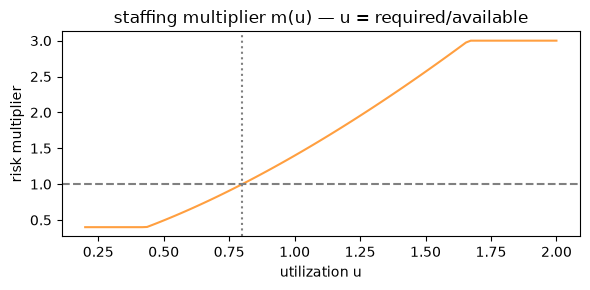

m(0.5)=0.49  m(0.8)=1.00  m(1.0)=1.40  m(1.5)=2.57


In [6]:
u = np.linspace(0.2, 2.0, 100)
target = 0.8
m = np.clip((u/target)**1.5, 0.4, 3.0)
plt.figure(figsize=(6,3))
plt.plot(u, m, color='#ff9f40'); plt.axhline(1, ls='--', color='gray'); plt.axvline(target, ls=':', color='gray')
plt.title('staffing multiplier m(u) — u = required/available'); plt.xlabel('utilization u'); plt.ylabel('risk multiplier'); plt.tight_layout(); plt.show()
print('m(0.5)=%.2f  m(0.8)=%.2f  m(1.0)=%.2f  m(1.5)=%.2f' % tuple(np.clip((np.array([0.5,0.8,1.0,1.5])/target)**1.5,0.4,3.0)))

## Decision

In [7]:
best = results.drop(index='prior (priority x metric rate)').sort_values('roc_auc', ascending=False)
winner = best.index[0]
decision = {
  'chosen_grain': 'B (single model, metric as feature)' if '(B)' in winner else 'A (per-metric)',
  'chosen_model': winner,
  'test_metrics': results.loc[winner].to_dict(),
  'prior_baseline': results.loc['prior (priority x metric rate)'].to_dict(),
  'top_drivers': [f for f,_ in drivers],
  'overlay': 'p = clip(p0 * (u/0.8)**1.5, 0..1), floor 0.4 cap 3.0',
  'caveat': 'labels are generator-derived; metrics likely optimistic vs real-world',
}
print(json.dumps(decision, indent=2))

{
  "chosen_grain": "B (single model, metric as feature)",
  "chosen_model": "HistGBM (B)",
  "test_metrics": {
    "roc_auc": 0.753,
    "pr_auc": 0.571,
    "brier": 0.1593
  },
  "prior_baseline": {
    "roc_auc": 0.699,
    "pr_auc": 0.433,
    "brier": 0.1723
  },
  "top_drivers": [
    "ticket_type",
    "sla_target_min",
    "priority",
    "metric",
    "queue"
  ],
  "overlay": "p = clip(p0 * (u/0.8)**1.5, 0..1), floor 0.4 cap 3.0",
  "caveat": "labels are generator-derived; metrics likely optimistic vs real-world"
}
